# 31 - When do neighbouring k modes diverge?

Notebook 30 shows a per-k-mode P(k) error in accDM runs (~0.7% max at f_acc = 0.1) that does not
respond to the integration tolerance, to birth breakpoints, or to finer k sampling. It is
deterministic per mode but not smooth in k.

Here 30 modes in a narrow band, k ∈ [0.100, 0.105]/Mpc, are requested as `k_output_values`, so CLASS
integrates each one exactly and prints its full time evolution. Physics is smooth across such a band,
so any jaggedness across the 30 modes is numerical. Tracking the jaggedness in time shows *when* the
modes separate, which points to the responsible event (a birth, an approximation switch, the start
of integration, ...).

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from classy import Class

A_REC = 1.0/1091.0
MASS, F_ACC, KAPPA, A_T, N_Q = 1e11, 0.1, 12.1, 0.133, 201
K_DENSE = np.linspace(0.100, 0.105, 30)          # 1/Mpc; CLASS allows at most 30 k outputs


def params(n_q=N_Q, k_out=K_DENSE):
    """Sink-off accDM run as in notebook 30, P(k) output plus dense k outputs."""
    ocdm = 0.12011/(1 + F_ACC*(1 - A_REC**KAPPA)/(1 + (A_REC/A_T)**KAPPA))
    return {'omega_b': 0.022383, 'omega_cdm': ocdm, '100*theta_s': 1.041783,
            'A_s': 2.1005829616811546e-9, 'n_s': 0.96605, 'tau_reio': 0.0543, 'N_ur': 0.00441,
            'output': 'mPk', 'P_k_max_1/Mpc': 1.0, 'z_max_pk': 0.0,
            'k_output_values': ','.join('{:.7f}'.format(k) for k in k_out),
            'gauge': 'synchronous', 'evolver': 0, 'ncdm_fluid_approximation': 3,
            'vary_Gamma_acc': 'yes', 'kappa_acc': KAPPA, 'a_t_acc': A_T,
            'f_acc': F_ACC, 'eta_acc': 1e11/MASS, 'm_acc_in_GeV': MASS, 'm_cdm_in_GeV': MASS,
            'N_ncdm': 2, 'deg_ncdm': '3, 1', 'm_ncdm': '0.02, {:.6e}'.format(MASS*1e9),
            'T_ncdm': '0.71611, 1', 'ncdm_quadrature_strategy': '0, 5',
            'ncdm_N_momentum_bins': '15, {:d}'.format(n_q)}


cosmo = Class()
cosmo.set(params())
try:
    cosmo.compute()
    perts = cosmo.get_perturbations()['scalar']
    pk = np.array([cosmo.pk(k, 0.0) for k in K_DENSE])
    bg = cosmo.get_background()
finally:
    cosmo.struct_cleanup()
    cosmo.empty()


def smooth_residual(x, y, deg=3):
    """y minus a degree-deg polynomial fit in x."""
    return y - np.polyval(np.polyfit(x - x.mean(), y, deg), x - x.mean())


print('{} modes, columns: {}'.format(len(perts), sorted(perts[0].keys())))

30 modes, columns: ['a', 'cs2_ncdm[0]', 'cs2_ncdm[1]', 'delta_b', 'delta_cdm', 'delta_dcdm', 'delta_g', 'delta_ncdm[0]', 'delta_ncdm[1]', 'delta_p_tot', 'delta_rho_tot', 'delta_ur', 'eta', 'eta_prime', 'h_prime', 'k_fss_acc[0]', 'k_fss_acc[1]', 'phi', 'phi_prime', 'pol0_g', 'pol1_g', 'pol2_g', 'psi', 'rho_plus_p_theta', 'shear_g', 'shear_ncdm[0]', 'shear_ncdm[1]', 'shear_ur', 'tau [Mpc]', 'theta_b', 'theta_cdm', 'theta_dcdm', 'theta_g', 'theta_ncdm[0]', 'theta_ncdm[1]', 'theta_ur', 'w_p[0]', 'w_p[1]', 'w_sigma[0]', 'w_sigma[1]', 'w_theta[0]', 'w_theta[1]', 'w_trial_1', 'w_trial_2']


## 1. Is P(k) jagged across the dense band?

Residual of ln P about a cubic in k. The requested k values are nodes of CLASS's k list, so no
interpolation is involved.

ln P residual across the band: rms 1.5e-03, max 3.2e-03


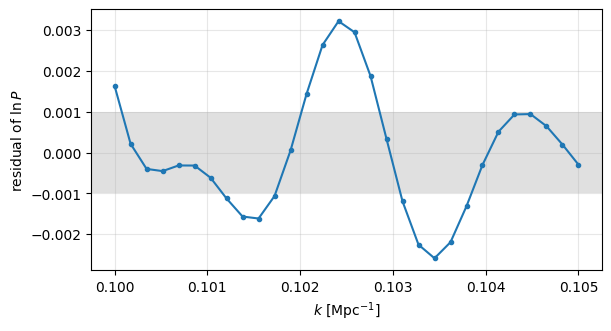

In [2]:
r_pk = smooth_residual(K_DENSE, np.log(pk))
print('ln P residual across the band: rms {:.1e}, max {:.1e}'.format(
    float(np.sqrt(np.mean(r_pk**2))), float(np.max(np.abs(r_pk)))))

fig, ax = plt.subplots(figsize=(6, 3.2), constrained_layout=True)
ax.plot(K_DENSE, r_pk, 'o-', ms=3)
ax.axhspan(-1e-3, 1e-3, color='0.88', lw=0)
ax.set_xlabel(r'$k\ [\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'residual of $\ln P$')
ax.grid(alpha=0.3)
plt.show()

## 2. When does the jaggedness appear?

Each mode's evolution is interpolated onto a common ln a grid. At every time, the 30 values of a
quantity are fitted with a cubic in k; the maximum residual (relative to the rms across modes) is
the jaggedness at that time. Grey lines: daughter births, found as jumps in the background daughter
density; dotted: a_t.

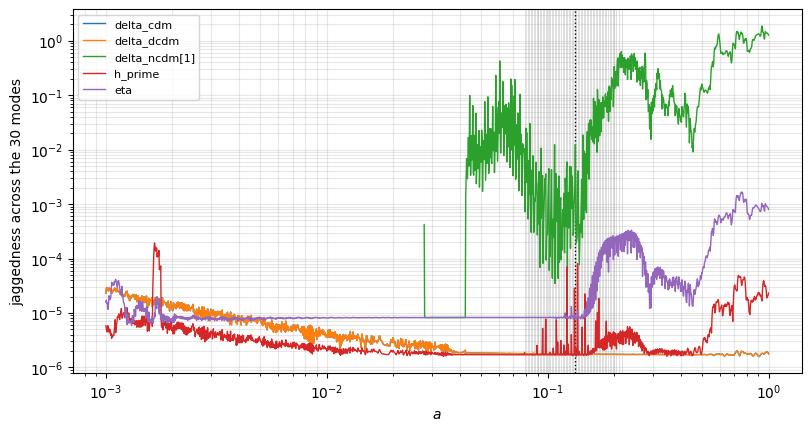

delta_cdm      jaggedness early 1.7e-05, today 1.8e-06, first exceeds 10x early level at a = nan
delta_dcdm     jaggedness early 1.7e-05, today 1.8e-06, first exceeds 10x early level at a = nan
delta_ncdm[1]  jaggedness early nan, today 1.3e+00, first exceeds 10x early level at a = nan
h_prime        jaggedness early 6.4e-06, today 2.3e-05, first exceeds 10x early level at a = 0.0016
eta            jaggedness early 8.7e-06, today 8.0e-04, first exceeds 10x early level at a = 0.1681
62 daughter births detected in the background, a from 0.0787 to 0.2161


In [3]:
LNA = np.linspace(np.log(1e-3), 0.0, 1500)
QUANTITIES = [q for q in ('delta_cdm', 'delta_dcdm', 'delta_ncdm[1]', 'h_prime', 'eta')
              if q in perts[0]]


def on_grid(pt, key):
    """One mode's column on the common ln a grid; CLASS repeats rows at approximation switches."""
    a = np.asarray(pt['a'])
    keep = np.append(np.diff(a) > 0, True)
    return np.interp(LNA, np.log(a[keep]), np.asarray(pt[key])[keep])


jagged = {}
for q in QUANTITIES:
    M = np.array([on_grid(pt, q) for pt in perts])            # (mode, time)
    res = np.array([smooth_residual(K_DENSE, M[:, j]) for j in range(M.shape[1])]).T
    scale = np.sqrt(np.mean(M**2, axis=0)) + 1e-300
    jagged[q] = np.max(np.abs(res), axis=0)/scale

# daughter births: upward jumps of rho_d a^3 in the background table
a_bg = 1.0/(1.0 + np.asarray(bg['z']))
order = np.argsort(a_bg)
a_bg = a_bg[order]
n_d = np.asarray(bg['(.)rho_ncdm[1]'])[order]*a_bg**3
jumps = np.diff(n_d)
births = a_bg[1:][jumps > 5*np.median(np.abs(jumps[jumps != 0]))]

fig, ax = plt.subplots(figsize=(8, 4.2), constrained_layout=True)
for a_b in births:
    ax.axvline(a_b, color='0.85', lw=0.6, zorder=0)
ax.axvline(A_T, color='k', ls=':', lw=1)
for q in QUANTITIES:
    ax.semilogy(np.exp(LNA), jagged[q], lw=1, label=q)
ax.set_xscale('log')
ax.set_xlabel(r'$a$')
ax.set_ylabel('jaggedness across the 30 modes')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which='both')
plt.show()

for q in QUANTITIES:
    j = jagged[q]
    onset = np.exp(LNA[np.argmax(j > 10*np.median(j[:200]))]) if np.any(j > 10*np.median(j[:200])) else float('nan')
    print('{:<14s} jaggedness early {:.1e}, today {:.1e}, first exceeds 10x early level at a = {:.4f}'.format(
        q, float(np.median(j[:200])), float(j[-1]), onset))
print('{} daughter births detected in the background, a from {:.4f} to {:.4f}'.format(
    len(births), float(births.min()) if len(births) else float('nan'),
    float(births.max()) if len(births) else float('nan')))

## 3. The two most different neighbours

The pair of adjacent modes whose ln P residuals differ most, and the relative difference of their
evolutions (after removing the smooth trend expected from Δk). Approximation switches (repeated τ
rows) are marked per mode.

worst neighbours: k = 0.10276 and 0.10293, ln P residuals +1.9e-03 and +3.4e-04
  k = 0.10276: 4131 output rows, approximation switches at a = 2.02e-04, 9.68e-04, 1.70e-03, 4.25e-02, 4.31e-02, 4.38e-02, 4.45e-02, 4.52e-02, 4.59e-02, 4.67e-02, 4.74e-02, 4.82e-02, 4.89e-02, 4.97e-02, 5.05e-02, 5.13e-02, 5.21e-02, 5.30e-02, 5.38e-02, 5.47e-02, 5.55e-02, 5.64e-02, 5.73e-02, 5.82e-02, 5.92e-02, 6.01e-02, 6.11e-02, 6.20e-02, 6.30e-02, 6.40e-02, 6.50e-02, 6.61e-02, 6.71e-02, 6.82e-02, 6.93e-02, 7.04e-02, 7.15e-02, 7.26e-02, 7.38e-02, 7.50e-02, 7.62e-02, 7.74e-02, 7.86e-02, 7.99e-02, 8.11e-02, 8.24e-02, 8.37e-02, 8.51e-02, 8.64e-02, 8.78e-02, 8.92e-02, 9.06e-02, 9.21e-02, 9.35e-02, 9.50e-02, 9.65e-02, 9.81e-02, 9.96e-02, 1.01e-01, 1.03e-01, 1.04e-01, 1.06e-01, 1.08e-01, 1.10e-01, 1.11e-01, 1.13e-01, 1.15e-01, 1.17e-01, 1.19e-01, 1.20e-01, 1.22e-01, 1.24e-01, 1.26e-01, 1.28e-01, 1.30e-01, 1.32e-01, 1.35e-01, 1.37e-01, 1.39e-01, 1.41e-01, 1.43e-01, 1.46e-01, 1.48e-01, 1.50e-01, 1.53e-01, 1.55e-0

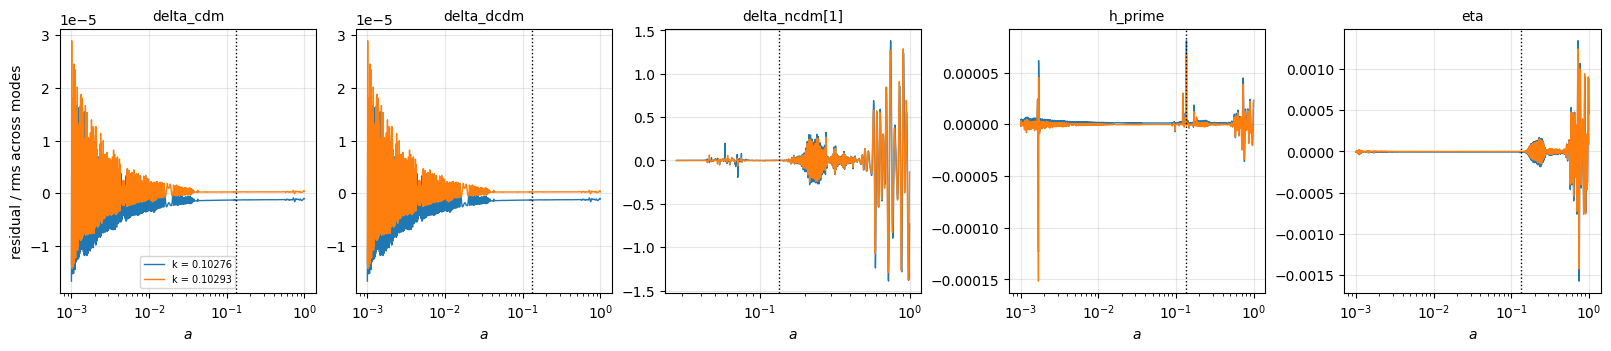

In [4]:
i = int(np.argmax(np.abs(np.diff(r_pk))))
pair = (i, i + 1)
print('worst neighbours: k = {:.5f} and {:.5f}, ln P residuals {:+.1e} and {:+.1e}'.format(
    K_DENSE[i], K_DENSE[i+1], r_pk[i], r_pk[i+1]))

for idx in pair:
    a = np.asarray(perts[idx]['a'])
    switches = a[:-1][np.diff(np.asarray(perts[idx]['tau [Mpc]'])) <= 0]
    print('  k = {:.5f}: {} output rows, approximation switches at a = {}'.format(
        K_DENSE[idx], len(a), ', '.join('{:.2e}'.format(s) for s in switches) or 'none'))

fig, axes = plt.subplots(1, len(QUANTITIES), figsize=(3.2*len(QUANTITIES), 3.4),
                         constrained_layout=True, squeeze=False)
for ax, q in zip(axes[0], QUANTITIES):
    M = np.array([on_grid(pt, q) for pt in perts])
    res = np.array([smooth_residual(K_DENSE, M[:, j]) for j in range(M.shape[1])]).T
    scale = np.sqrt(np.mean(M**2, axis=0)) + 1e-300
    for idx in pair:
        ax.semilogx(np.exp(LNA), res[idx]/scale, lw=1, label='k = {:.5f}'.format(K_DENSE[idx]))
    ax.axvline(A_T, color='k', ls=':', lw=1)
    ax.set_title(q, fontsize=10)
    ax.set_xlabel(r'$a$')
    ax.grid(alpha=0.3)
axes[0, 0].set_ylabel('residual / rms across modes')
axes[0, 0].legend(fontsize=7)
plt.show()

## 4. Does the jaggedness converge with the number of daughter bins?

Hypothesis: the daughter's momentum integral is undersampled. Each bin free-streams with phase
k v(q) tau, which winds many times across the velocity range at k ~ 0.1, so a finite q-grid gives a
quasi-random sum. Prediction: the jaggedness of ln P and of the daughter delta falls steadily with
N_Q. If it stays flat up to 1601 bins, the hypothesis is wrong.

Also printed: the daughter delta relative to CDM today. For free-streaming particles at these k the
physical value should be small.

N_Q =    51  lnP rms 1.4e-03  max 3.1e-03  | delta_d jaggedness 1.25  delta_d/delta_cdm 1.56e-02  (3 s)
N_Q =   201  lnP rms 1.5e-03  max 3.2e-03  | delta_d jaggedness 1.26  delta_d/delta_cdm 1.59e-02  (8 s)
N_Q =   801  lnP rms 1.5e-03  max 3.2e-03  | delta_d jaggedness 1.26  delta_d/delta_cdm 1.59e-02  (49 s)
N_Q =  1601  lnP rms 1.5e-03  max 3.2e-03  | delta_d jaggedness 1.26  delta_d/delta_cdm 1.59e-02  (214 s)


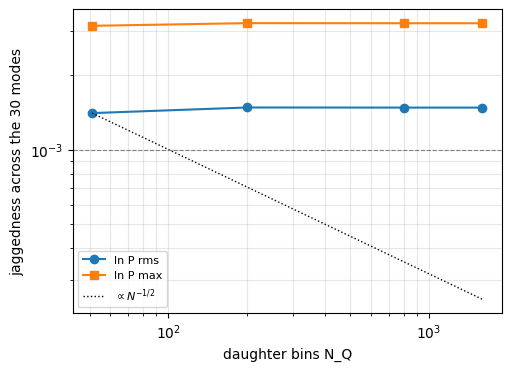

In [2]:
import time

N_SCAN = [51, 201, 801, 1601]


def scan_point(n_q):
    cosmo = Class()
    cosmo.set(params(n_q))
    t0 = time.time()
    try:
        cosmo.compute()
        pts = cosmo.get_perturbations()['scalar']
        p = np.array([cosmo.pk(k, 0.0) for k in K_DENSE])
    finally:
        cosmo.struct_cleanup()
        cosmo.empty()
    r = smooth_residual(K_DENSE, np.log(p))
    d_d = np.array([pt['delta_ncdm[1]'][-1] for pt in pts])      # today
    d_c = np.array([pt['delta_cdm'][-1] for pt in pts])
    rms = lambda x: float(np.sqrt(np.mean(x**2)))
    return dict(n_q=n_q, sec=time.time() - t0,
                lnP_rms=rms(r), lnP_max=float(np.max(np.abs(r))),
                dd_jag=float(np.max(np.abs(smooth_residual(K_DENSE, d_d))))/rms(d_d),
                dd_over_dc=rms(d_d)/rms(d_c))


scan = []
for n_q in N_SCAN:
    try:
        scan.append(scan_point(n_q))
    except Exception as err:
        print('N_Q = {}: FAILED - {}'.format(n_q, err))
        continue
    s = scan[-1]
    print('N_Q = {:>5d}  lnP rms {:.1e}  max {:.1e}  | delta_d jaggedness {:.2f}  delta_d/delta_cdm {:.2e}  ({:.0f} s)'.format(
        s['n_q'], s['lnP_rms'], s['lnP_max'], s['dd_jag'], s['dd_over_dc'], s['sec']))

n = np.array([s['n_q'] for s in scan])
fig, ax = plt.subplots(figsize=(5, 3.6), constrained_layout=True)
ax.loglog(n, [s['lnP_rms'] for s in scan], 'o-', label='ln P rms')
ax.loglog(n, [s['lnP_max'] for s in scan], 's-', label='ln P max')
ax.loglog(n, scan[0]['lnP_rms']*np.sqrt(n[0]/n), 'k:', lw=1, label=r'$\propto N^{-1/2}$')
ax.axhline(1e-3, color='grey', ls='--', lw=0.8)
ax.set_xlabel('daughter bins N_Q')
ax.set_ylabel('jaggedness across the 30 modes')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which='both')
plt.show()

## 5. Physical oscillation or numerical scatter?

The jaggedness is converged in N_Q, tolerance and time sampling. Hypothesis: it is a real
oscillation of the daughter density in k. Every daughter is born with the same momentum, so the
distance travelled by today has a maximum D_max over birth times, and delta_d ~ cos(k D_max) does not
phase-mix away. Its period 2 pi / D_max (~5e-4 to 1.5e-3 /Mpc) is finer than CLASS's k spacing.

Test: 30 modes packed into k in [0.1000, 0.1015] (spacing 5e-5). A physical oscillation traces a
smooth curve here; numerical scatter stays scattered. Smoothness metric: rms of the second difference
over rms of the detrended signal (~0.1 for a well-sampled sinusoid of period 1e-3, ~2 or more for
random scatter). A sine fit gives the period and D = 2 pi / period.

delta_d/delta_cdm  smoothness 0.07   best period 1.30e-03 /Mpc (D = 4828 Mpc), sine explains 100%
ln P               smoothness 0.07   best period 1.31e-03 /Mpc (D = 4804 Mpc), sine explains 100%


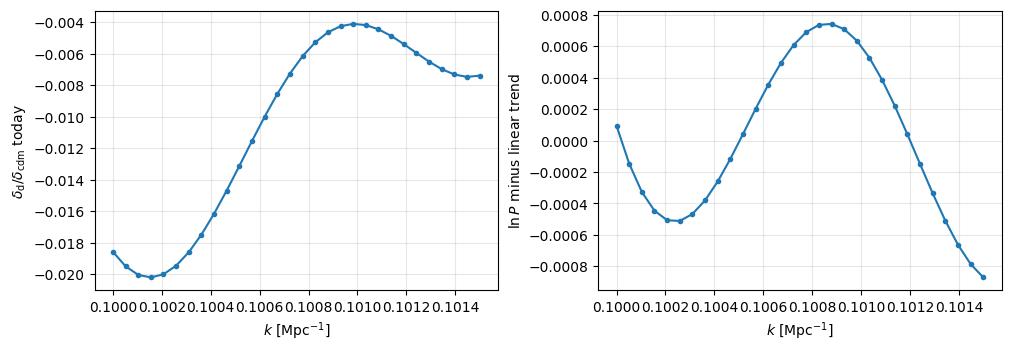

In [4]:
K_FINE = np.linspace(0.1000, 0.1015, 30)

cosmo = Class()
cosmo.set(params(201, K_FINE))
try:
    cosmo.compute()
    pts_f = cosmo.get_perturbations()['scalar']
    pk_f = np.array([cosmo.pk(k, 0.0) for k in K_FINE])
finally:
    cosmo.struct_cleanup()
    cosmo.empty()

ratio = np.array([pt['delta_ncdm[1]'][-1]/pt['delta_cdm'][-1] for pt in pts_f])
lnp = np.log(pk_f)


def smoothness(y):
    detr = smooth_residual(K_FINE, y, deg=1)
    return float(np.std(np.diff(y, 2))/np.std(detr))


def sine_fit(y):
    """Best period (1/Mpc) of a sinusoid plus linear trend, and the variance fraction it explains."""
    x = K_FINE - K_FINE.mean()
    best = (np.nan, -np.inf)
    for period in np.geomspace(1.5e-4, 3e-3, 600):
        w = 2*np.pi/period
        A = np.column_stack([np.ones_like(x), x, np.sin(w*x), np.cos(w*x)])
        coef, *_ = np.linalg.lstsq(A, y, rcond=None)
        r2 = 1 - np.sum((y - A @ coef)**2)/np.sum((y - np.polyval(np.polyfit(x, y, 1), x))**2)
        if r2 > best[1]:
            best = (period, r2)
    return best


for name, y in (('delta_d/delta_cdm', ratio), ('ln P', lnp)):
    period, r2 = sine_fit(y)
    print('{:<18s} smoothness {:.2f}   best period {:.2e} /Mpc (D = {:.0f} Mpc), sine explains {:.0%}'.format(
        name, smoothness(y), period, 2*np.pi/period, r2))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), constrained_layout=True)
axes[0].plot(K_FINE, ratio, 'o-', ms=3)
axes[0].set_ylabel(r'$\delta_{\rm d}/\delta_{\rm cdm}$ today')
axes[1].plot(K_FINE, smooth_residual(K_FINE, lnp, deg=1), 'o-', ms=3)
axes[1].set_ylabel(r'$\ln P$ minus linear trend')
for ax in axes:
    ax.set_xlabel(r'$k\ [\mathrm{Mpc}^{-1}]$')
    ax.grid(alpha=0.3)
plt.show()